In [78]:
# -*- coding: utf-8 -*-
#datasets from https://www.kaggle.com/datasets/mmoreaux/audio-cats-and-dogs

import librosa, librosa.display
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
from scipy.io import wavfile
import os
from tqdm import tqdm
import tensorflow as tf
import glob
import pandas as pd
import random

def mfcc(file):
    f, sr = librosa.load(file)
    padding = np.zeros(400000 - np.shape(f)[0])
    signal_length = np.concatenate([f, padding], axis=0)
    mfcc = librosa.feature.mfcc(y=signal_length, sr=sr)

    return mfcc

x_train = list()
x_test = list()
y_train = list()
y_test = list()

file_train = glob.glob('./train/*')
random.shuffle(file_train)

file_test = glob.glob('./test/*')
random.shuffle(file_test)
for f in file_train:
    x_train.append(mfcc(f))
    if 'cat' in f:
        y_train.append([0,1])
    else:
        y_train.append([1,0])

for f in file_test:
    x_test.append(mfcc(f))
    if 'cat' in f:
        y_test.append([0,1])
    else:
        y_test.append([1,0])

Y_train = np.array(y_train)
X_train = np.subtract(x_train,np.mean(x_train))/np.std(x_train)
Y_test = np.array(y_test)
X_test = np.subtract(x_test,np.mean(x_test))/np.std(x_train)


# X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
# X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

# print(X_test.shape,X_train.shape,Y_train.shape,Y_test.shape)

In [79]:
print(X_test.shape,X_train.shape,Y_train.shape,Y_test.shape)
X_train

(67, 20, 782) (210, 20, 782) (210, 2) (67, 2)


array([[[-3.82717477, -3.49709018, -3.30151818, ..., -4.45961232,
         -4.45961232, -4.45961232],
        [ 0.9707325 ,  1.27418085,  1.361474  , ...,  0.19460269,
          0.19460269,  0.19460269],
        [ 0.68228368,  0.73608439,  0.67588031, ...,  0.19460269,
          0.19460269,  0.19460269],
        ...,
        [ 0.07401419,  0.07619077,  0.11121704, ...,  0.19460269,
          0.19460269,  0.19460269],
        [ 0.08294281,  0.03031276, -0.01133926, ...,  0.19460269,
          0.19460269,  0.19460269],
        [ 0.12581104,  0.07484165,  0.02094434, ...,  0.19460269,
          0.19460269,  0.19460269]],

       [[-2.80877058, -1.68444762, -0.97793685, ..., -5.16131179,
         -5.16131179, -5.16131179],
        [ 1.84647127,  2.05590018,  2.04742306, ...,  0.19460269,
          0.19460269,  0.19460269],
        [-0.21876321, -0.58757164, -0.76677995, ...,  0.19460269,
          0.19460269,  0.19460269],
        ...,
        [ 0.40754232,  0.41363529,  0.35674281, ...,  

In [120]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten, BatchNormalization
from keras.layers import Conv2D, MaxPooling2D
from keras.optimizers import SGD
model = keras.Sequential([
keras.layers.LSTM(256, input_shape=(20,782), return_sequences=True),
keras.layers.Dropout(0.2),
keras.layers.LSTM(128, return_sequences=True),
keras.layers.Dropout(0.2),
keras.layers.Dense(32, activation='relu'),
keras.layers.Dense(16,activation='relu'),

keras.layers.Dense(8,activation='relu'),
keras.layers.Flatten(),
keras.layers.Dense(2, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy'
, metrics= ['accuracy'])

model.fit(X_train,Y_train,epochs=20,validation_data=(X_test,Y_test),batch_size=64)

Epoch 1/20
4/4 [==============================] - 7s 599ms/step - loss: 0.6845 - accuracy: 0.5190 - val_loss: 0.6754 - val_accuracy: 0.5821
Epoch 2/20
4/4 [==============================] - 1s 245ms/step - loss: 0.6572 - accuracy: 0.5952 - val_loss: 0.6458 - val_accuracy: 0.5821
Epoch 3/20
4/4 [==============================] - 1s 244ms/step - loss: 0.6316 - accuracy: 0.5952 - val_loss: 0.6052 - val_accuracy: 0.5970
Epoch 4/20
4/4 [==============================] - 1s 253ms/step - loss: 0.5840 - accuracy: 0.7048 - val_loss: 0.5356 - val_accuracy: 0.8507
Epoch 5/20
4/4 [==============================] - 1s 265ms/step - loss: 0.5069 - accuracy: 0.8429 - val_loss: 0.4411 - val_accuracy: 0.8209
Epoch 6/20
4/4 [==============================] - 1s 241ms/step - loss: 0.4171 - accuracy: 0.8381 - val_loss: 0.3720 - val_accuracy: 0.8507
Epoch 7/20
4/4 [==============================] - 2s 389ms/step - loss: 0.3787 - accuracy: 0.8571 - val_loss: 0.3769 - val_accuracy: 0.8209
Epoch 8/20
4/4 [====

In [121]:
model.evaluate(X_test,Y_test)

3/3 [==============================] - 0s 41ms/step - loss: 0.2258 - accuracy: 0.9104


[0.2257739007472992, 0.9104477763175964]

In [122]:
y_predict = model.predict(X_test)
label = ['dog','cat']
print(Y_test.shape)


3/3 [==============================] - 2s 59ms/step
(67, 2)


In [14]:
# data = spect('./test/dog_barking_112.wav')
# data = np.array(data)
# print(data.shape)
# data = data.reshape(1,data.shape[0],data.shape[1],1)
# y_predict = model.predict(data)
# print(label[y_predict.argmax()])

(20, 782)
1/1 [==============================] - 0s 81ms/step
dog


In [85]:
print(y_predict)

[[0.80984074 0.19015928]
 [0.5006703  0.49932957]
 [0.990253   0.00974692]
 [0.03950174 0.9604983 ]
 [0.03595473 0.96404535]
 [0.04209919 0.95790076]
 [0.98026496 0.01973516]
 [0.04694508 0.9530548 ]
 [0.48219025 0.5178098 ]
 [0.06834565 0.9316543 ]
 [0.02796282 0.97203714]
 [0.11710033 0.88289964]
 [0.10983638 0.8901636 ]
 [0.12412646 0.87587357]
 [0.11641815 0.8835819 ]
 [0.9745747  0.02542528]
 [0.9893494  0.01065055]
 [0.12251653 0.8774834 ]
 [0.988172   0.011828  ]
 [0.0391858  0.9608142 ]
 [0.02449683 0.97550315]
 [0.02802395 0.971976  ]
 [0.13532364 0.86467636]
 [0.9587578  0.04124209]
 [0.96218276 0.03781718]
 [0.03221327 0.9677868 ]
 [0.10685317 0.8931468 ]
 [0.08714666 0.91285336]
 [0.6511202  0.34887984]
 [0.10261333 0.89738667]
 [0.99002683 0.00997315]
 [0.83588326 0.16411684]
 [0.9858925  0.01410746]
 [0.98542273 0.01457718]
 [0.8296885  0.17031161]
 [0.66554433 0.3344557 ]
 [0.32760274 0.67239726]
 [0.9130728  0.08692724]
 [0.44172212 0.55827785]
 [0.40149876 0.5985012 ]


In [123]:
y_predicted_classes = np.argmax(y_predict, axis=1)
Y_test_classes = np.argmax(Y_test, axis=1)
Y_test_classes
y_predicted_classes

array([0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       0])

In [124]:
cm = tf.math.confusion_matrix(labels=Y_test_classes,predictions=y_predicted_classes)
cm

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[26,  2],
       [ 4, 35]], dtype=int32)>

Text(95.72222222222221, 0.5, 'Truth')

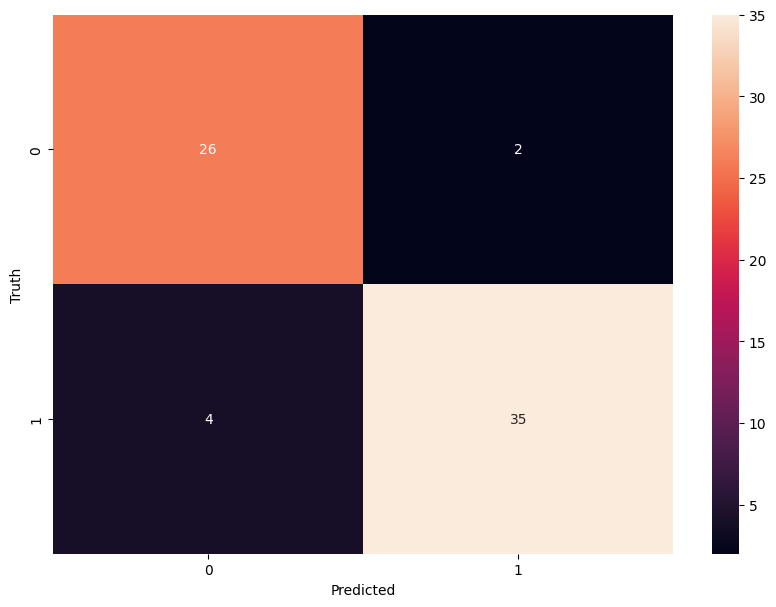

In [125]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')